<a href="https://colab.research.google.com/github/chrishan-92/ComputerVisionAssignment01/blob/Master/Comp_VIsion_Assigment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/tmp/ipython-input-1904395918.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(out_arr, mode="L").save(output_path)


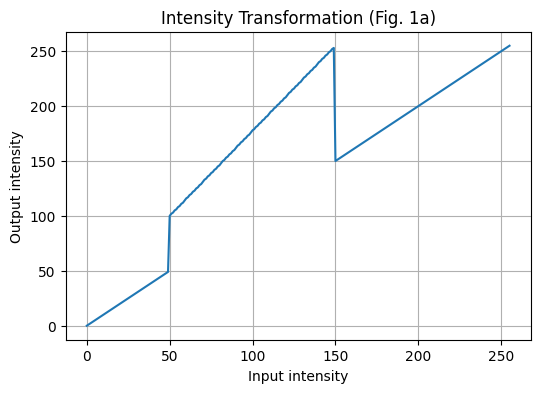

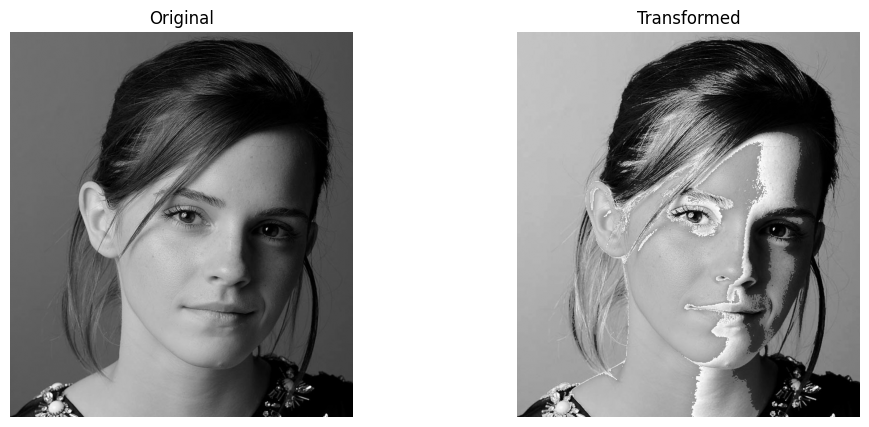

✅ Saved: /content/drive/MyDrive/Computer Vision/Assignment 1/emma_transformed.jpg


In [2]:
from PIL import Image
import numpy as np
import os, matplotlib.pyplot as plt

# ----- Fig. 1a LUT -----
def build_fig1a_lut():
    lut = np.zeros(256, dtype=np.uint8)
    # 0..49 : y = x
    for x in range(0, 50):
        lut[x] = x
    # 50..149 : line 50→100, 150→255
    for x in range(50, 150):
        y = 100 + 1.55 * (x - 50)
        lut[x] = np.clip(int(round(y)), 0, 255)
    # 150..255 : y = x (discontinuity at 150 handled by jump)
    for x in range(150, 256):
        lut[x] = x
    return lut

def apply_lut_to_image(image_path, output_path, lut=None):
    if lut is None:
        lut = build_fig1a_lut()
    img = Image.open(image_path).convert("L")
    arr = np.array(img, dtype=np.uint8)
    out_arr = lut[arr]
    Image.fromarray(out_arr, mode="L").save(output_path)
    return arr, out_arr

# ----- Your path -----
in_path = "/content/drive/MyDrive/Computer Vision/Assignment 1/emma.jpg"
root, ext = os.path.splitext(in_path)
out_path = root + "_transformed" + ext

# ----- Run -----
lut = build_fig1a_lut()
orig, trans = apply_lut_to_image(in_path, out_path, lut=lut)

# ----- Show curve + images -----
x = np.arange(256)
plt.figure(figsize=(6,4))
plt.plot(x, lut); plt.grid(True)
plt.title("Intensity Transformation (Fig. 1a)")
plt.xlabel("Input intensity"); plt.ylabel("Output intensity")
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(orig, cmap="gray", vmin=0, vmax=255); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(trans, cmap="gray", vmin=0, vmax=255); plt.title("Transformed"); plt.axis("off")
plt.show()

print("✅ Saved:", out_path)

Input image: /content/drive/MyDrive/Computer Vision/Assignment 1/brain_proton_density_slice.png
Suggested WM range (a,b): 15, 168
Suggested GM range (a,b): 168, 194


/tmp/ipython-input-1549183687.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr, mode="L").save(path)


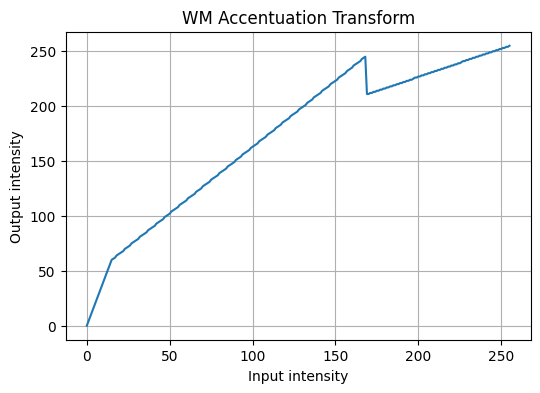

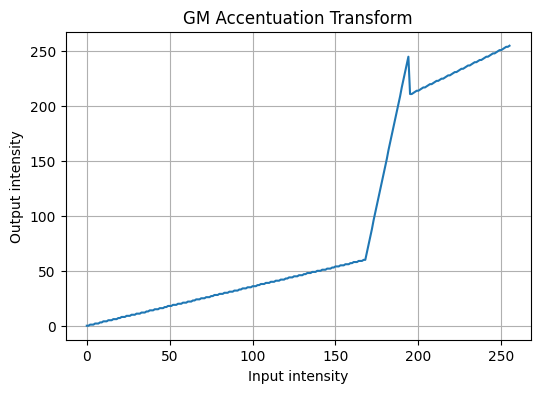

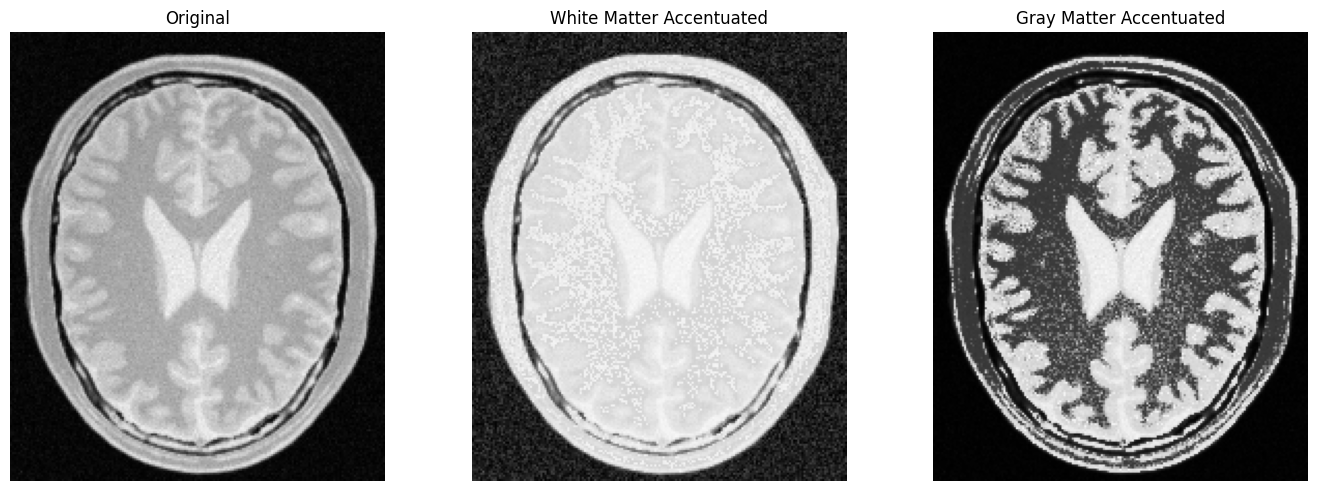

Saved files:
  WM: /content/drive/MyDrive/Computer Vision/Assignment 1/brain_proton_density_slice_wm.png
  GM: /content/drive/MyDrive/Computer Vision/Assignment 1/brain_proton_density_slice_gm.png


In [6]:
#==== Question 2 ====#

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ----------- CONFIG -----------
IN_PATH = "/content/drive/MyDrive/Computer Vision/Assignment 1/brain_proton_density_slice.png"

# Optional: manually override breakpoints if you already know good ones.
# Set to None to auto-pick from percentiles.
MANUAL_WM_RANGE = None   # e.g., (50, 175)
MANUAL_GM_RANGE = None   # e.g., (175, 215)

# How aggressively to expand the target band and compress the rest.
PRE_TOP      = 60    # max output for below-a range
FOCUS_TOP    = 245   # max output for a..b target band
POST_BOTTOM  = 210   # min output for above-b range
BACKGROUND_CUTOFF = 5  # ignore intensities <= this when estimating percentiles
# ------------------------------

# --- helpers ---
def load_gray(path):
    return np.array(Image.open(path).convert("L"), dtype=np.uint8)

def save_gray(arr, path):
    Image.fromarray(arr, mode="L").save(path)

def build_focus_lut(a, b, pre_top=60, focus_top=245, post_bottom=210):
    a = int(max(0, min(254, a)))
    b = int(max(a+1, min(255, b)))
    lut = np.zeros(256, dtype=np.uint8)

    # [0, a] -> [0, pre_top]  (compress shadows)
    for x in range(0, a+1):
        y = (pre_top / max(a, 1)) * x
        lut[x] = np.clip(int(round(y)), 0, 255)

    # [a, b] -> [pre_top, focus_top]  (expand target band)
    for x in range(a+1, b+1):
        y = pre_top + (focus_top - pre_top) * (x - a) / (b - a)
        lut[x] = np.clip(int(round(y)), 0, 255)

    # [b, 255] -> [post_bottom, 255]  (compress highlights)
    for x in range(b+1, 256):
        y = post_bottom + (255 - post_bottom) * (x - b) / (255 - b)
        lut[x] = np.clip(int(round(y)), 0, 255)

    return lut

def apply_lut(img_u8, lut):
    return lut[img_u8]

def suggest_ranges(arr_u8, bg_cutoff=5):
    """Suggest (a,b) from robust percentiles of non-background pixels."""
    v = arr_u8.flatten()
    v = v[v > bg_cutoff]         # drop near-black background
    if v.size < 50:
        # fallback if image is too small or all background
        return (40, 175), (175, 215)

    p20 = int(np.percentile(v, 20))
    p50 = int(np.percentile(v, 50))
    p80 = int(np.percentile(v, 80))
    # WM darker -> lower-mid band; GM -> mid-high band
    wm_range = (p20, p50)
    gm_range = (p50, p80)
    return wm_range, gm_range

# --- pipeline ---
img = load_gray(IN_PATH)

# Auto-suggest ranges if not provided
wm_range_auto, gm_range_auto = suggest_ranges(img, bg_cutoff=BACKGROUND_CUTOFF)
wm_a, wm_b = MANUAL_WM_RANGE if MANUAL_WM_RANGE is not None else wm_range_auto
gm_a, gm_b = MANUAL_GM_RANGE if MANUAL_GM_RANGE is not None else gm_range_auto

print(f"Input image: {IN_PATH}")
print(f"Suggested WM range (a,b): {wm_a}, {wm_b}")
print(f"Suggested GM range (a,b): {gm_a}, {gm_b}")

# Build LUTs
lut_wm = build_focus_lut(wm_a, wm_b, PRE_TOP, FOCUS_TOP, POST_BOTTOM)
lut_gm = build_focus_lut(gm_a, gm_b, PRE_TOP, FOCUS_TOP, POST_BOTTOM)

# Apply
out_wm = apply_lut(img, lut_wm)
out_gm = apply_lut(img, lut_gm)

# Save results
root, ext = os.path.splitext(IN_PATH)
wm_path = root + "_wm.png"
gm_path = root + "_gm.png"
save_gray(out_wm, wm_path)
save_gray(out_gm, gm_path)

# --- Plots: two separate figures for the transform curves ---
x = np.arange(256)

plt.figure(figsize=(6,4))
plt.plot(x, lut_wm)
plt.title("WM Accentuation Transform")
plt.xlabel("Input intensity"); plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(x, lut_gm)
plt.title("GM Accentuation Transform")
plt.xlabel("Input intensity"); plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

# --- Visualize images (side-by-side for quick inspection) ---
plt.figure(figsize=(14,5))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray", vmin=0, vmax=255); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(out_wm, cmap="gray", vmin=0, vmax=255); plt.title("White Matter Accentuated"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(out_gm, cmap="gray", vmin=0, vmax=255); plt.title("Gray Matter Accentuated"); plt.axis("off")
plt.tight_layout()
plt.show()

print("Saved files:")
print("  WM:", wm_path)
print("  GM:", gm_path)
